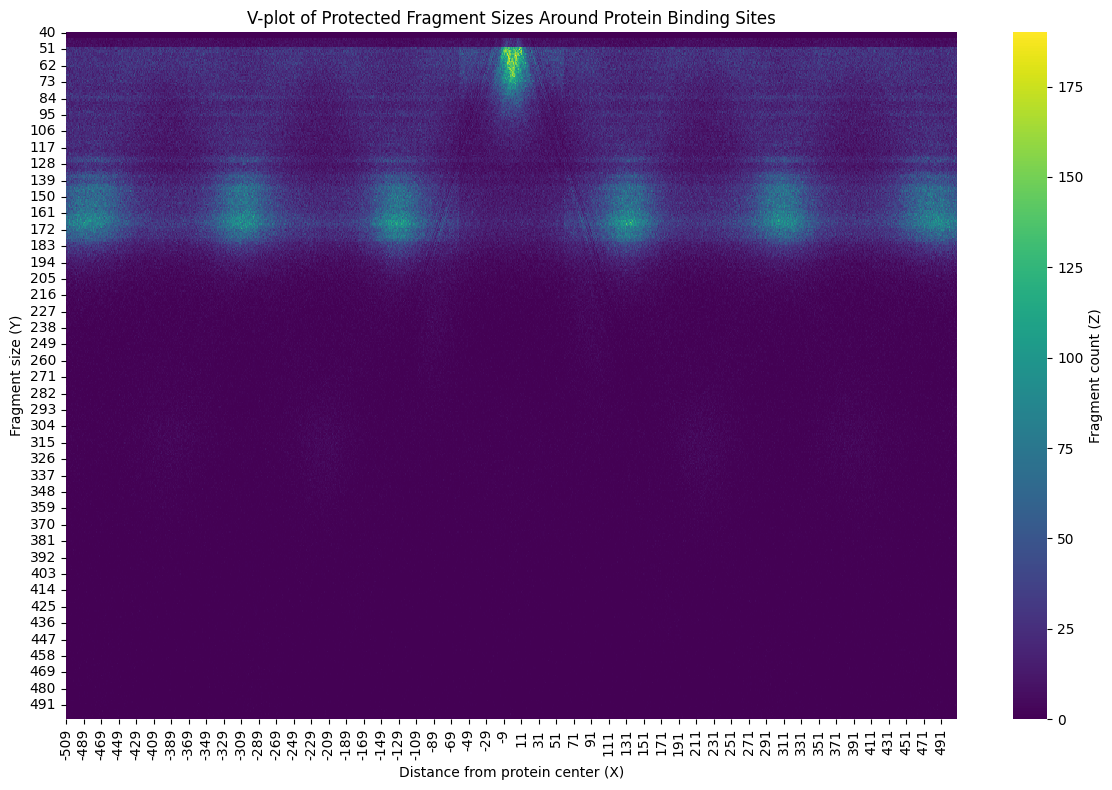

In [2]:
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict

#first im extracting the gz using gzip and then im extracting the data into a default dict
filename = "mapped.bed.gz"
counter = defaultdict(int)
with gzip.open(filename, 'rt') as f:  # 'rt' = read text mode
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) < 11:
            continue  #im skip malformed lines
        try:
            c1 = (int(parts[2]) + int(parts[3])) // 2
            c2 = (int(parts[8]) + int(parts[9])) // 2
            x = c2 - c1
            y = int(parts[9]) - int(parts[8])
            counter[(x, y)] += 1
        except ValueError:
            continue  #im skip non-integer lines (e.g. headers)
#now to converts into a dataframe
df = pd.DataFrame([
    {"X": x, "Y": y, "Z": z} for (x, y), z in counter.items()
])
#to convert the dataframe into a heat map
heatmap_data = df.pivot_table(index='Y', columns='X', values='Z', fill_value=0)
#now plotting the v-plot
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='viridis', cbar_kws={'label': 'Fragment count (Z)'})
plt.title("V-plot of Protected Fragment Sizes Around Protein Binding Sites")
plt.xlabel("Distance from protein center (X)")
plt.ylabel("Fragment size (Y)")
plt.tight_layout()
plt.show()
